In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pickle
import time
import seaborn as sns
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds
from efficient_fpt.multi_stage_cy import compute_loss_parallel, print_num_threads
import pymc as pm
import pytensor 
import pytensor.tensor as pt 
from pytensor.graph import Apply, Op


data = pickle.load(open("addm_data_20251015-163921.pkl", "rb"))


In [2]:
!lscpu

Architecture:            x86_64
  CPU op-mode(s):        32-bit, 64-bit
  Address sizes:         52 bits physical, 57 bits virtual
  Byte Order:            Little Endian
CPU(s):                  192
  On-line CPU(s) list:   0-191
Vendor ID:               AuthenticAMD
  Model name:            AMD EPYC 9684X 96-Core Processor
    CPU family:          25
    Model:               17
    Thread(s) per core:  1
    Core(s) per socket:  96
    Socket(s):           2
    Stepping:            2
    Frequency boost:     enabled
    CPU max MHz:         3715.4290
    CPU min MHz:         1500.0000
    BogoMIPS:            5100.26
    Flags:               fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mc
                         a cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall n
                         x mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_go
                         od nopl nonstop_tsc cpuid extd_apicid aperfmperf rapl p
                         ni pclmulqdq monitor sss

In [3]:
import psutil 
import os 
for k in ["OMP_NUM_THREADS", "OMP_THREAD_LIMIT", "OMP_DYNAMIC"]:
    print(k, "=", os.environ.get(k))
print_num_threads()

OMP_NUM_THREADS = None
OMP_THREAD_LIMIT = None
OMP_DYNAMIC = None
Number of available threads: 64


In [4]:
DATA_TYPE = np.float64

a = data["a"] # decision threshold  
print(a)
b = data["b"] # slope of collapsing boundary 
x0 = data["x0"] # initial starting point? 
eta_true = data["eta"] # scaling factor against the option not being fixated 
kappa_true = data["kappa"] # parametrizes whole drift..? 
r1_data = data["r1_data"] # reward value of option 1 
r2_data = data["r2_data"] # reward value of option 2 
flag_data = data["flag_data"].astype(np.int32) # what is this 

sigma = data["sigma"] # diffusion noise 
T = data["T"] # max time 

mu1_true_data = kappa_true * (r1_data - eta_true * r2_data)
mu2_true_data = kappa_true * (eta_true * r1_data - r2_data)

mu_true_data = data["mu_array_padded_data"].astype(DATA_TYPE)
sacc_data = data["sacc_array_padded_data"].astype(DATA_TYPE) # what is the sacc_data? 
length_data = data["d_data"].astype(np.int32)
rt_data = data["decision_data"][:, 0].astype(DATA_TYPE)
choice_data = data["decision_data"][:, 1].astype(np.int32)

num_data, max_d = mu_true_data.shape
print(num_data, max_d)

2.1
50000 12


In [5]:
print(data['a'])
print(data['b'])
print(data['x0'])
print(data['eta'])
print(data['kappa'])

2.1
0.3
-0.2
0.7
0.5


In [6]:
# smaller subset 

a_small = data["a"]
b_small = data["b"]
x0_small = data["x0"]
eta_small = data["eta"]
kappa_small = data["kappa"]
r1_data_small = data["r1_data"][:1000]
r2_data_small = data["r2_data"][:1000]
flag_data_small = data["flag_data"][:1000].astype(np.int32)
sigma_small = data["sigma"]
T_small = data["T"]
mu1_true_data_small = kappa_small * (r1_data_small - eta_small * r2_data_small)
mu2_true_data_small = kappa_small * (eta_small * r1_data_small - r2_data_small)
mu_true_data_small = data["mu_array_padded_data"][:1000].astype(DATA_TYPE)
sacc_data_small = data["sacc_array_padded_data"][:1000].astype(DATA_TYPE)
length_data_small = data["d_data"][:1000].astype(np.int32)
rt_data_small = data["decision_data"][:1000, 0].astype(DATA_TYPE)
choice_data_small = data["decision_data"][:1000, 1].astype(np.int32)

num_data_small, max_d_small = mu_true_data_small.shape
print(num_data_small, max_d_small)

1000 12


In [7]:
print(sacc_data[210])

[0.         0.96606344 1.45508996 0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]


In [8]:
print(rt_data)

[3.508225 1.070135 2.813685 ... 0.554615 1.290325 1.698795]


In [9]:
num_iter = 5
start_time = time.time()
for _ in range(num_iter):
    loss = compute_loss_parallel(
        mu1_true_data_small,
        mu2_true_data_small,
        rt_data_small,
        choice_data_small,
        flag_data_small,
        sacc_data_small,
        length_data_small,
        max_d_small,
        sigma_small,
        a_small,
        b_small,
        x0_small,
        num_threads=64,
    )
    print(loss)
end_time = time.time()
print(f"Likelihood evaluation time: {(end_time - start_time) / num_iter:.3f} s")

1.4938145464848105
1.4938145464848107
1.4938145464848107
1.4938145464848103
1.49381454648481
Likelihood evaluation time: 0.041 s


In [10]:
num_iter = 5
start_time = time.time()
for _ in range(num_iter):
    loss = compute_loss_parallel(
        mu1_true_data,
        mu2_true_data,
        rt_data,
        choice_data,
        flag_data,
        sacc_data,
        length_data,
        max_d,
        sigma,
        a,
        b,
        x0,
        num_threads=64,
    )
    print(loss)
end_time = time.time()
print(f"Likelihood evaluation time: {(end_time - start_time) / num_iter:.3f} s")

1.4853344770222021
1.4853344770222026
1.4853344770222021
1.4853344770222021
1.485334477022203
Likelihood evaluation time: 0.609 s


50000


(array([3.52768527e-04, 8.81921319e-04, 1.05830558e-03, 2.46937969e-03,
        2.46937969e-03, 4.76237512e-03, 5.29152791e-03, 5.46791217e-03,
        6.70260202e-03, 1.14649771e-02, 1.44635096e-02, 1.76384264e-02,
        1.79911949e-02, 2.01078061e-02, 2.89270192e-02, 2.76923294e-02,
        3.26310888e-02, 3.63351583e-02, 3.80990010e-02, 4.53307558e-02,
        5.43263532e-02, 6.04998025e-02, 6.22636451e-02, 6.80843258e-02,
        7.40813908e-02, 8.34297567e-02, 8.78393633e-02, 9.48947339e-02,
        1.09534628e-01, 1.21175989e-01, 1.29995202e-01, 1.39343568e-01,
        1.54159846e-01, 1.68799740e-01, 1.76913416e-01, 1.95962917e-01,
        2.06722357e-01, 2.31768923e-01, 2.35825761e-01, 2.56639104e-01,
        2.76041373e-01, 2.84860586e-01, 2.87859118e-01, 2.82567590e-01,
        2.50465654e-01, 1.67035898e-01, 7.72563075e-02, 1.21705142e-02,
        1.76384264e-04, 0.00000000e+00, 0.00000000e+00, 5.29152791e-04,
        2.06369589e-02, 7.02009370e-02, 1.25409211e-01, 1.672122

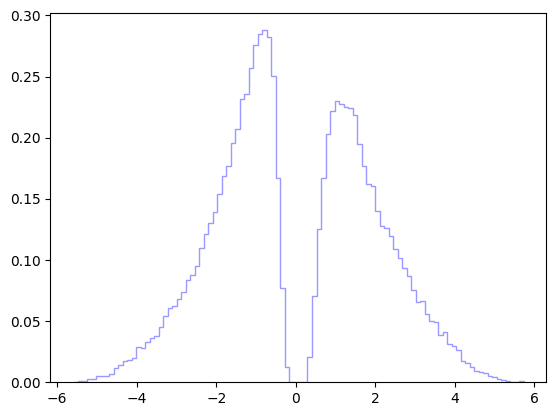

In [11]:
print(len(rt_data))
plt.hist(rt_data*choice_data, bins=100,
    histtype="step",
    color="blue",
    density=True,
    alpha=0.4,)

In [12]:
T = 2.1 / 0.3 
rng = np.random.default_rng() 
fixations = rng.gamma(6, 0.1, size=1000)
sacc_array = np.insert(np.cumsum(fixations), 0, 0)
sacc_array = sacc_array[sacc_array < T]
print(sacc_array.shape)

(12,)


In [13]:
# Wrap blackbox likelihood function as a pytensor Op

from pytensor.graph import Apply, Op 

class ADDMLik(Op):         
    def make_node(self, mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b, x0): 
        mu1 = pt.as_tensor_variable(mu1) 
        mu2 = pt.as_tensor_variable(mu2) 
        rt = pt.as_tensor_variable(rt) 
        choice = pt.as_tensor_variable(choice) 
        max_d = pt.as_tensor_variable(max_d)
        sigma = pt.as_tensor_variable(sigma)
        a = pt.as_tensor_variable(a)
        b = pt.as_tensor_variable(b)
        x0 = pt.as_tensor_variable(x0)
        flag = pt.as_tensor_variable(flag) 
        sacc = pt.as_tensor_variable(sacc) 
        length = pt.as_tensor_variable(length) 

        inputs = [mu1, mu2, rt, choice,flag, sacc, length, max_d, sigma, a, b, x0]
        outputs = [pt.scalar(dtype=DATA_TYPE)] 
        return Apply(self, inputs, outputs)
    
    def perform(self, node, inputs, outputs): 
        mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b, x0 = inputs 
        output = compute_loss_parallel(
            mu1,
            mu2,
            rt,
            choice,
            flag,
            sacc,
            length,
            max_d,
            sigma,
            a,
            b,
            x0,
            num_threads=64,
        ) 
        loglik = -len(rt) * output
        outputs[0][0] = np.array(loglik, dtype=DATA_TYPE)

In [14]:
loglike_op = ADDMLik()
test_loglike = loglike_op(mu1_true_data, mu2_true_data, rt_data, choice_data, flag_data, sacc_data, length_data, max_d, sigma, a, b, x0,)

In [15]:
pytensor.dprint(test_loglike, print_type=True)

ADDMLik [id A] <Scalar(float64, shape=())>
 ├─ [ 0.95  0. ... .15 -0.55] [id B] <Vector(float64, shape=(50000,))>
 ├─ [-0.1  -0. ... .55 -1.15] [id C] <Vector(float64, shape=(50000,))>
 ├─ [3.508225 ... 1.698795] [id D] <Vector(float64, shape=(50000,))>
 ├─ [ 1 -1  1 ... 1  1 -1] [id E] <Vector(int32, shape=(50000,))>
 ├─ [0 0 1 ... 1 1 1] [id F] <Vector(int32, shape=(50000,))>
 ├─ [[0. ... ]] [id G] <Matrix(float64, shape=(50000, 12))>
 ├─ [7 3 4 ... 2 3 3] [id H] <Vector(int32, shape=(50000,))>
 ├─ 12 [id I] <Scalar(int8, shape=())>
 ├─ 1 [id J] <Scalar(int8, shape=())>
 ├─ 2.1 [id K] <Scalar(float64, shape=())>
 ├─ 0.3 [id L] <Scalar(float64, shape=())>
 └─ -0.2 [id M] <Scalar(float64, shape=())>


In [16]:
test_loglike.eval()

array(-74266.72385111)

In [19]:
def custom_dist_addm_lik(mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b, x0): # Customdist always takes data as first argument? 
    loglik = loglike_op(mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b, x0)
    return loglik

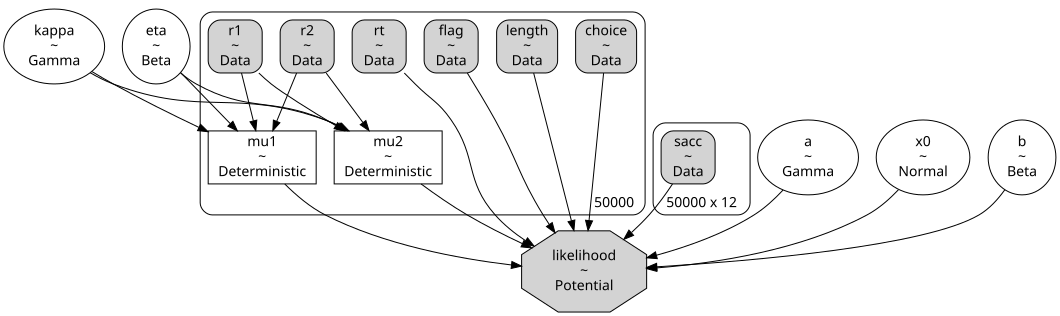

In [18]:
# define pymc model 
from pymc import model_to_graphviz

with pm.Model() as model: 
    rt = pm.Data("rt", rt_data)
    choice = pm.Data("choice", choice_data)
    flag = pm.Data("flag", flag_data)
    sacc = pm.Data("sacc", sacc_data)
    length = pm.Data("length", length_data)
    r1 = pm.Data("r1", r1_data)
    r2 = pm.Data("r2", r2_data)

    eta = pm.Beta("eta", alpha=2, beta=2, initval=0.7)
    kappa = pm.Gamma("kappa", alpha=2, beta=0.25, initval=0.5)
    a = pm.Gamma("a", alpha=2.0, beta=0.5, initval=2.1)
    b = pm.Beta("b", alpha=2, beta=2, initval=0.3)
    x0 = pm.Normal("x0", mu=0, sigma=0.5, initval=-0.2)
    
    mu1 = pm.Deterministic("mu1", kappa * (r1 - eta * r2))
    mu2 = pm.Deterministic("mu2", kappa * (eta * r1 - r2))

    # define likelihood 
    pm.Potential("likelihood", custom_dist_addm_lik(mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b, x0))


model_to_graphviz(model)

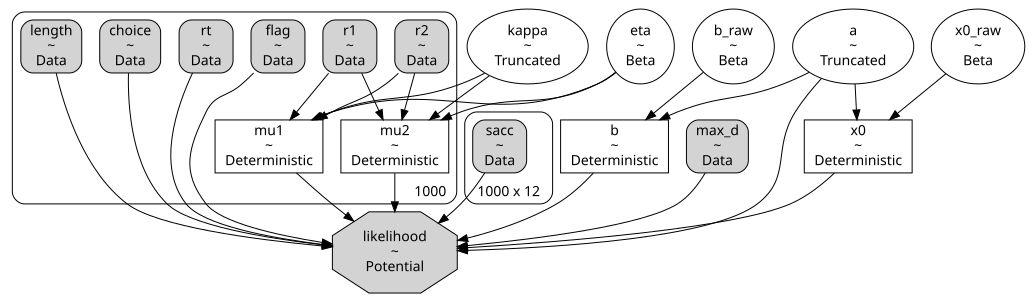

In [28]:
# model with smaller dataset 

# define pymc model 
from pymc import model_to_graphviz
max_rt = np.max(rt_data_small)

with pm.Model() as model_small: 
    rt = pm.Data("rt", rt_data_small)
    choice = pm.Data("choice", choice_data_small)
    flag = pm.Data("flag", flag_data_small)
    sacc = pm.Data("sacc", sacc_data_small)
    length = pm.Data("length", length_data_small)
    r1 = pm.Data("r1", r1_data_small)
    r2 = pm.Data("r2", r2_data_small)
    max_d = pm.Data("max_d", max_d_small)

    eta = pm.Beta("eta", alpha=2, beta=2, initval=0.7)
    kappa = pm.Truncated("kappa", pm.Gamma.dist(alpha=2, beta=4), lower=0, upper=2, initval=0.5)
    a = pm.Truncated("a", pm.Gamma.dist(alpha=2.0, beta=1), lower=0, upper=10, initval=2.1)

    b_raw = pm.Beta("b_raw", alpha=2, beta=2, initval=0.3) # upper bound should be determined by a / maximum RT
    b_transform = pm.Deterministic("b", b_raw * (a / max_rt))

    x0_raw = pm.Beta("x0_raw", alpha=2.0, beta=2.0)
    x0_transform = pm.Deterministic("x0", -a + 2.0 * a * x0_raw)

    # constant params 
    # b_transform = 0.3 
    # kappa = 0.5 
    # eta = 0.7
    # x0_transform = -0.2
    # a = 2.1 

    mu1 = pm.Deterministic("mu1", kappa * (r1 - eta * r2))
    mu2 = pm.Deterministic("mu2", kappa * (eta * r1 - r2))

    # define likelihood 
    pm.Potential("likelihood", custom_dist_addm_lik(mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b_transform, x0_transform))


model_to_graphviz(model_small)

In [21]:
# test logp calc time 

num_iter = 5 

logp = model_small.compile_logp()
initial_point = model_small.initial_point()
print(initial_point)
start = time.time()
for _ in range(num_iter): 
    lp = logp(initial_point)
    print(lp)
end = time.time()
print("Average logp eval time:", (end - start)/num_iter)

/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


{'kappa_interval__': array(-1.09861229)}
-1494.7129104560995
-1494.7129104560988
-1494.7129104560995
-1494.7129104560986
-1494.7129104560995
Average logp eval time: 0.02653021812438965


In [29]:
with model_small: 
    step = pm.Metropolis(scaling=0.005) # can choose the initial step size 
    idata = pm.sample(draws=1000, tune=1000, chains=2, step=step, mp_ctx='spawn', discard_tuned_samples=False)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [eta]
>Metropolis: [kappa]
>Metropolis: [a]
>Metropolis: [b_raw]
>Metropolis: [x0_raw]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1843 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [30]:
import arviz as az 

az.summary(idata, var_names = ['eta', 'kappa', 'a', 'b', 'x0'])
# az.summary(idata, var_names = ['kappa'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta,0.733,0.025,0.686,0.782,0.001,0.001,372.0,401.0,1.00
kappa,0.496,0.017,0.463,0.527,0.001,0.001,258.0,459.0,1.00
a,2.104,0.041,2.029,2.182,0.004,0.002,119.0,261.0,1.01
b,0.303,0.017,0.271,0.335,0.002,0.001,121.0,253.0,1.01
x0,-0.132,0.029,-0.183,-0.072,0.001,0.001,553.0,464.0,1.00


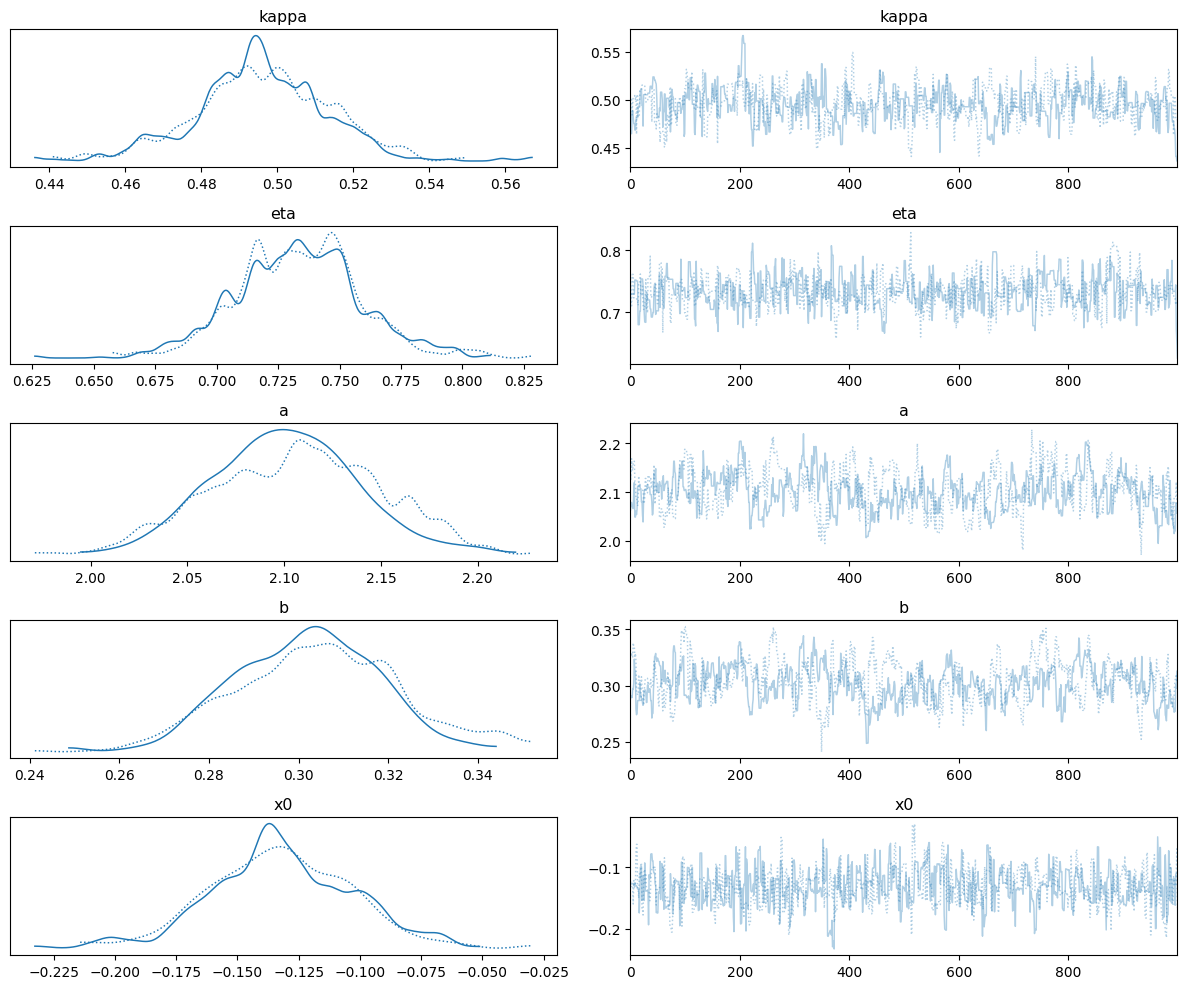

In [32]:
import matplotlib.pyplot as plt

az.plot_trace(idata, var_names = ['kappa', 'eta', 'a', 'b', 'x0'])
plt.tight_layout()


In [30]:
# define MLE model for simulated dataset 

max_rt = np.max(rt_data_small)  # used to scale b

with pm.Model() as model_mle:
    
    rt = pm.Data("rt", rt_data_small)
    choice = pm.Data("choice", choice_data_small)
    flag = pm.Data("flag", flag_data_small)
    sacc = pm.Data("sacc", sacc_data_small)
    length = pm.Data("length", length_data_small)
    r1 = pm.Data("r1", r1_data_small)
    r2 = pm.Data("r2", r2_data_small)
    max_d = pm.Data("max_d", max_d_small)

    eta   = pm.Uniform("eta", lower=0.0, upper=1.0, initval=0.7)
    kappa = pm.Uniform("kappa", lower=0.0, upper=2.0, initval=0.5)
    a     = pm.Uniform("a", lower=0.0, upper=10.0, initval=2.1)

    b_raw  = pm.Uniform("b_raw", lower=0.0, upper=1.0, initval=0.3)
    x0_raw = pm.Uniform("x0_raw", lower=0.0, upper=1.0, initval=0.5)


    b  = pm.Deterministic("b", b_raw * (a / max_rt))
    x0 = pm.Deterministic("x0", -a + 2.0 * a * x0_raw)

    # --- Drift parameters ---
    mu1 = pm.Deterministic("mu1", kappa * (r1 - eta * r2))
    mu2 = pm.Deterministic("mu2", kappa * (eta * r1 - r2))

    # --- Likelihood (log-likelihood as Potential) ---
    # custom_dist_addm_lik should return (sum) log-likelihood.
    pm.Potential(
        "likelihood",
        custom_dist_addm_lik(
            mu1,
            mu2,
            rt,
            choice,
            flag,
            sacc,
            length,
            max_d,
            sigma,  # assumed defined outside
            a,
            b,
            x0,
        ),
    )

    # --- Run MLE / MAP optimization ---
    mle_result = pm.find_MAP(method="Powell")  # or pm.optimize()

print(mle_result)  # dict of MLE/MAP estimates for eta, kappa, a, b_raw, x0_raw, etc.

Output()

{'eta_interval__': array(nan), 'kappa_interval__': array(nan), 'a_interval__': array(nan), 'b_raw_interval__': array(nan), 'x0_raw_interval__': array(nan), 'eta': array(nan), 'kappa': array(nan), 'a': array(nan), 'b_raw': array(nan), 'x0_raw': array(nan), 'b': array(nan), 'x0': array(nan), 'mu1': array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, na